In [31]:
from pathlib import Path

import numpy as np
import torch

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib


In [32]:
# =========================
# CONFIGURACIÓN GENERAL
# =========================

DATASET_DIR = Path("dataset_split")

SAVE_DIR = Path("results/elm")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = SAVE_DIR / "cnn_elm.pkl"          # modelo ELM guardado
SCALER_PATH = SAVE_DIR / "scaler.pkl"          # scaler para features
HISTORY_PATH = SAVE_DIR / "history_cnn_elm.pt" # historial (estilo 02)

FIGURES_DIR = SAVE_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 384
BATCH_SIZE = 32
NUM_WORKERS = 2

# En ELM no hay entrenamiento iterativo por épocas,
# pero se mantiene variable por consistencia con el 02
EPOCHS = 1

# Hiperparámetros ELM (los que te dieron 0.95)
HIDDEN_DIM = 3000
REG = 1e-4
ACTIVATION = "tanh"


In [33]:
# =========================
# VARIABLES DE CONTROL
# =========================

best_val_acc = 0.0
best_elm = None


In [34]:
# =========================
# DEVICE
# =========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)


Usando dispositivo: cuda


In [35]:
# =========================
# TRANSFORMS
# =========================

transform_eval = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [36]:
# =========================
# DATASETS
# =========================

train_ds = datasets.ImageFolder(DATASET_DIR / "train", transform=transform_eval)
val_ds   = datasets.ImageFolder(DATASET_DIR / "val",   transform=transform_eval)
test_ds  = datasets.ImageFolder(DATASET_DIR / "test",  transform=transform_eval)

class_names = train_ds.classes
num_classes = len(class_names)

print("Clases:", class_names)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


Clases: ['Aedes aegypti', 'Culex quinquefasciatus']
Train: 560 | Val: 120 | Test: 120


In [37]:
# =========================
# DATALOADERS
# =========================

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,          # ⚠️ importante para features
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


In [38]:
# =========================
# CARGAR CNN ENTRENADA
# =========================

from models.cnn.cnn_pure import CNNPure

cnn_model = CNNPure(num_classes=num_classes).to(device)

CNN_MODEL_PATH = Path("results/cnn/cnn_pure.pth")

if CNN_MODEL_PATH.exists():
    print("Modelo CNN entrenado encontrado. Cargando pesos...")
    cnn_model.load_state_dict(torch.load(CNN_MODEL_PATH, map_location=device))
    cnn_model.eval()
else:
    raise RuntimeError(
        "No se encontró cnn_pure.pth. "
        "Primero debes entrenar el modelo CNN (02_cnn_training.ipynb)."
    )


Modelo CNN entrenado encontrado. Cargando pesos...


In [39]:
# =========================
# EXTRACCIÓN DE FEATURES
# =========================

def extract_features(dataloader, model, device):
    features = []
    labels = []

    model.eval()
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)

            # Usamos SOLO el extractor de características
            feats = model.features(x)

            features.append(feats.cpu().numpy())
            labels.append(y.numpy())

    features = np.vstack(features)
    labels = np.concatenate(labels)

    return features, labels


In [40]:
# =========================
# OBTENER FEATURES
# =========================

X_train, y_train = extract_features(train_loader, cnn_model, device)
X_val,   y_val   = extract_features(val_loader,   cnn_model, device)
X_test,  y_test  = extract_features(test_loader,  cnn_model, device)

print("Features extraídas:")
print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


Features extraídas:
X_train: (560, 256)
X_val  : (120, 256)
X_test : (120, 256)


In [41]:
# =========================
# NORMALIZACIÓN DE FEATURES
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Guardamos el scaler (buenas prácticas)
joblib.dump(scaler, SCALER_PATH)

print("Features normalizadas correctamente")


Features normalizadas correctamente


In [42]:
# =========================
# DEFINICIÓN DEL MODELO ELM
# =========================

class ELM:
    def __init__(self, input_dim, hidden_dim, output_dim, activation, reg):
        self.W = np.random.randn(input_dim, hidden_dim)
        self.b = np.random.randn(hidden_dim)
        self.reg = reg

        if activation == "tanh":
            self.activation = np.tanh
        elif activation == "relu":
            self.activation = lambda x: np.maximum(0, x)
        else:  # sigmoid
            self.activation = lambda x: 1 / (1 + np.exp(-x))

    def fit(self, X, T):
        H = self.activation(X @ self.W + self.b)
        I = np.eye(H.shape[1])
        self.beta = np.linalg.inv(H.T @ H + self.reg * I) @ H.T @ T

    def predict(self, X):
        H = self.activation(X @ self.W + self.b)
        return np.argmax(H @ self.beta, axis=1)


In [43]:
# =========================
# PREPARAR LABELS
# =========================

Y_train_oh = np.eye(num_classes)[y_train]
Y_val_oh   = np.eye(num_classes)[y_val]


In [44]:
# =========================
# ENTRENAMIENTO ELM (CON VALIDACIÓN)
# =========================

from sklearn.metrics import accuracy_score

best_val_acc = 0.0
best_elm = None

for epoch in range(EPOCHS):  # EPOCHS = 1, se mantiene por coherencia

    elm = ELM(
        input_dim=X_train.shape[1],
        hidden_dim=HIDDEN_DIM,
        output_dim=num_classes,
        activation=ACTIVATION,
        reg=REG
    )

    # "Entrenamiento" (solución analítica)
    elm.fit(X_train, Y_train_oh)

    # Validación
    val_pred = elm.predict(X_val)
    val_acc = accuracy_score(y_val, val_pred)

    print(f"[Epoch {epoch+1}/{EPOCHS}] Val Accuracy: {val_acc:.4f}")

    # Selección del mejor modelo (igual que en el CNN)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_elm = elm


[Epoch 1/1] Val Accuracy: 0.9750


In [45]:
# =========================
# GUARDAR MEJOR MODELO ELM
# =========================

joblib.dump(best_elm, MODEL_PATH)
print(f"Mejor modelo CNN-ELM guardado en: {MODEL_PATH}")


Mejor modelo CNN-ELM guardado en: results\elm\cnn_elm.pkl


In [46]:
# =========================
# EVALUACIÓN FINAL EN TEST
# =========================

y_test_pred = best_elm.predict(X_test)

acc  = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, average="binary")
rec  = recall_score(y_test, y_test_pred, average="binary")
f1   = f1_score(y_test, y_test_pred, average="binary")

print("\n=== MÉTRICAS FINALES CNN-ELM ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")



=== MÉTRICAS FINALES CNN-ELM ===
Accuracy : 0.9833
Precision: 0.9833
Recall   : 0.9833
F1-score : 0.9833


In [47]:
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))



Classification Report:
                        precision    recall  f1-score   support

         Aedes aegypti       0.98      0.98      0.98        60
Culex quinquefasciatus       0.98      0.98      0.98        60

              accuracy                           0.98       120
             macro avg       0.98      0.98      0.98       120
          weighted avg       0.98      0.98      0.98       120

Confusion Matrix:
[[59  1]
 [ 1 59]]


In [48]:
from sklearn.metrics import confusion_matrix


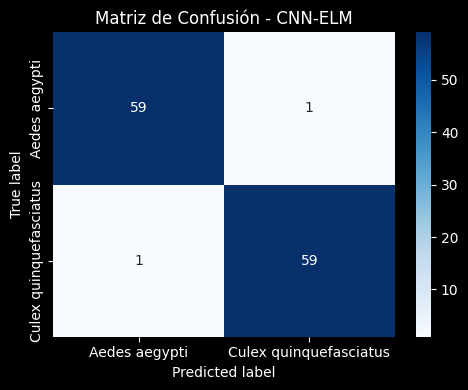

In [49]:
# =========================
# GRÁFICA: MATRIZ DE CONFUSIÓN
# =========================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Matriz de Confusión - CNN-ELM")
plt.tight_layout()
plt.show()
